## Implement calibrator for Tree.

---

Background: In the Black-Scholes model, volatility is a key parameter that determines option price. In a Balanced Binomial Tree (i.e. risk-neutral up step probability = 0.5, risk-neutral down step probability=0.5) the same role is played by step size: higher step is like higher volatility, it results in higher option prices. Also, there is a 1-1 correspondence between step size and price if all other parameters are fixed.

---

**Task**: Write a calibrate method which, for a given number of steps parameter, computes the up step size for which a Balanced Binomial Tree model returns the specified price for a given European call. (In practice, option prices can be observed in the market, so it makes sense to assume it is given).
- Demonstrate the calibrate method for various input parameters (same contract with a few different number of steps (don't forget to scale the discount factor to keep interest rates at); calibrate one-step tree for various contracts (different expires and strike levels, at interest rate)).
- Make simple plots to illustrate results.

Hint: To do it you will need to use a root solver, I recommend using scipy.optimize.minimize.

In [1]:
from typing import Union, List

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

In [151]:
# Helper functions from lectures

def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)

def calcBalancedDownStep(
        spot_mult_up: float,
        discount_factor: float
) -> (float, float):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

def create_spot_tree(
    spot: float,
    spot_mult_up: float,
    spot_mult_down: float,
    steps: int,
) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]

    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level

    return tree

def price_european_call(
    spot: float,
    spot_mult_up: float,
    discount_factor: float,
    K: float,
    steps: int,
) -> float:
    """Price a European call on a balanced binomial tree."""
    spot_mult_down = calcBalancedDownStep(spot_mult_up, discount_factor)
    spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)

    cv = [[float("nan")] * len(level) for level in spot_tree]

    for i, s in enumerate(spot_tree[-1]):
        cv[-1][i] = discount_factor**steps * european_call_payoff(s, K)

    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            cv[step][i] = 0.5 * cv[step + 1][i] + 0.5 * cv[step + 1][i + 1]

    return cv[0][0]


In [152]:
# Black-Scholes as the target market price from lecture 1

def black_scholes_eur_call(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
) -> float:
    """Black-Scholes pricer of European call option on non-dividend-paying stock."""
    # check conditions
    assert sigma > 0

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
    d2 = d1 - sigma * T**0.5

    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


In [ ]:
def calibrate_with_minimize(
    spot: float,
    discount_factor: float,
    K: float,
    steps: int,
    target_price: float,
) -> float:
    """Find the up-step multiplier so that the balanced binomial tree
    prices the eur call at target_price.

    Use minimize on the squared pricing error.
    """

    def objective(x):
        u = x[0]
        if u <= 1.0 / discount_factor:  # no-arbitrage
            return 1e6

        model_price = price_european_call(
            spot, u, discount_factor, K, steps
        )
        return (model_price - target_price) ** 2

    result = minimize(objective, x0=[1.1], method="Nelder-Mead")

    return float(result.x[0])


In [204]:
from scipy.optimize import minimize_scalar

def calibrate(
    spot: float,
    discount_factor: float,
    K: float,
    steps: int,
    target_price: float,
) -> float:
    """Find the up-step multiplier so that the balanced binomial tree
    prices the eur call at target_price.

    Use minimize_scalar on the squared pricing error.
    """
    lower = (1.0 / discount_factor) + 1e-5
    upper = (3.0 / discount_factor) - 1e-5

    def objective(x):

        model_price = price_european_call(
            spot, x, discount_factor, K, steps
        )
        return (model_price - target_price) ** 2

    res = minimize_scalar(objective, bounds=(lower, upper), method='bounded')
    return res.x

## Same contract, varying number of steps

Fixed annual interest rate and true up-step.
Generate target price from a 1000-step tree, then calibrated trees with different step counts.

In [205]:
spot = 100.0
K = 110.0
annual_discount_factor = 0.95

true_u_annual = 1.20
N_ref = 1000
df_ref = annual_discount_factor ** (1.0 / N_ref)
u_ref = true_u_annual ** (1.0 / np.sqrt(N_ref))
target_price = price_european_call(spot, u_ref, df_ref, K, N_ref)

print("Target price:", target_price)

Target price: 5.349131559356517


In [206]:
step_counts = [1, 2, 5, 10, 20, 50, 100, 250, 500]
calibrated_u_annual = []

for N in step_counts:
    df_step = annual_discount_factor ** (1.0 / N)
    u_step = calibrate(spot, df_step, K, N, target_price)
    u_ann = u_step**np.sqrt(N)
    calibrated_u_annual.append(u_ann)

    prediction = price_european_call(
        spot, u_step, df_step, K, N
    )
    print(
        f"For steps ={N:3d}: the calibrated annual u = {u_ann:.4f},"
        f" and the predicted price = {prediction:.6f}"
    )

For steps =  1: the calibrated annual u = 1.2126, and the predicted price = 5.349132
For steps =  2: the calibrated annual u = 1.2203, and the predicted price = 5.349138
For steps =  5: the calibrated annual u = 1.2189, and the predicted price = 5.349054
For steps = 10: the calibrated annual u = 1.2072, and the predicted price = 5.349189
For steps = 20: the calibrated annual u = 1.2069, and the predicted price = 5.349203
For steps = 50: the calibrated annual u = 1.2045, and the predicted price = 5.349052
For steps =100: the calibrated annual u = 1.2025, and the predicted price = 5.349147
For steps =250: the calibrated annual u = 1.2012, and the predicted price = 5.349142
For steps =500: the calibrated annual u = 1.2005, and the predicted price = 5.349967


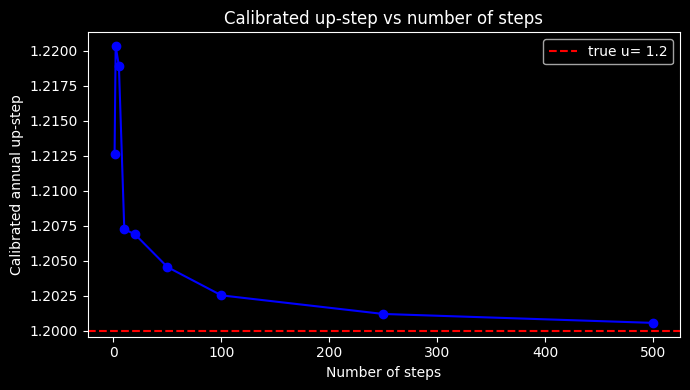

In [207]:
plt.figure(figsize=(7, 4))
plt.plot(step_counts, calibrated_u_annual, "o-", color="blue")
plt.axhline(
    true_u_annual, linestyle="--", color="red",
    label=f"true u= {true_u_annual}"
)
plt.xlabel("Number of steps")
plt.ylabel("Calibrated annual up-step")
plt.title("Calibrated up-step vs number of steps")
plt.legend()
plt.tight_layout()
plt.show()

## 1-step tree with varying the strike

Market prices for different strike prices and the calibrated 1-step tree for each one

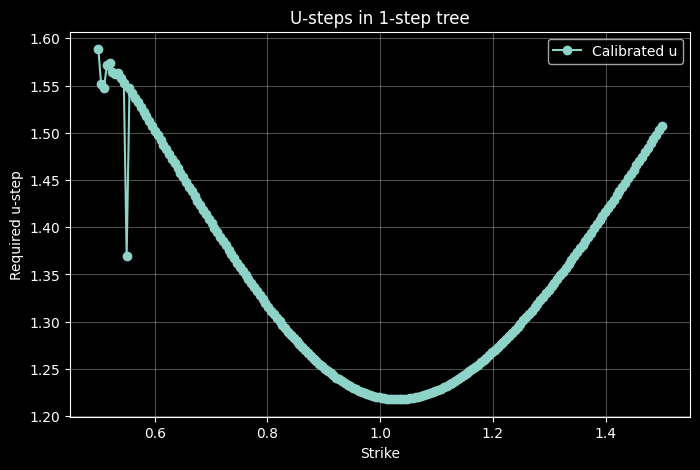

In [211]:
# Parameters for the Black-Scholes
spot = 1
r = 0.05
sigma = 0.2
T = 1

annual_df = np.exp(-r * T)
strikes = np.linspace(0.5, 1.5, 200)
cal_u_by_strike = []

for K_val in strikes:

    target_price = black_scholes_eur_call(spot, K_val, r, sigma, T)

    u_cal = calibrate(spot, annual_df, K_val, 1, target_price)

    cal_u_by_strike.append(u_cal)

plt.figure(figsize=(8, 5))
plt.plot(strikes, cal_u_by_strike, "o-", label="Calibrated u")
plt.xlabel("Strike")
plt.ylabel("Required u-step")
plt.title("U-steps in 1-step tree")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

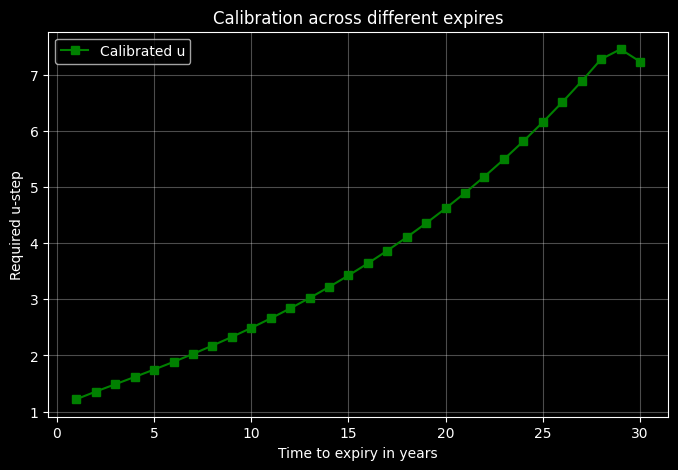

In [212]:
spot = 1.0
K = 1.0
r = 0.05
sigma = 0.20

expires = np.linspace(1, 30, 30)
cal_u_by_expiry = []

for T_val in expires:
    target_price = black_scholes_eur_call(spot, K, r, sigma, T_val)

    discount = np.exp(-r * T_val)

    u_cal = calibrate(spot, discount, K, 1, target_price)
    cal_u_by_expiry.append(u_cal)

plt.figure(figsize=(8, 5))
plt.plot(expires, cal_u_by_expiry, "s-", color="green", label="Calibrated u")
plt.xlabel("Time to expiry in years")
plt.ylabel("Required u-step")
plt.title("Calibration across different expires")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()